# Análisis de Convergencia y Precisión
### Determinando Iteraciones, Errores y Visualización

**Magíster en Ciencia de Datos e Inteligencia Artificial** · Universidad Andrés Bello
*Maidana, J.P. (2026)*

---

Versión ejecutable del apunte homónimo sobre **simulación Monte Carlo**. Todo el código corre de principio a fin; modifica parámetros y vuelve a ejecutar para ver cómo cambian el error estándar, la convergencia y los intervalos de confianza.

**Cómo usarlo:** ejecuta las celdas en orden (`Shift`+`Enter`). La primera celda de código carga dependencias y define la paleta; córrela antes que el resto.

## Requisitos

- Python ≥ 3.9
- `numpy`, `scipy`, `matplotlib`

Instalación (si fuese necesario):

```bash
pip install numpy scipy matplotlib
```

In [1]:
import numpy as np
import scipy
from scipy import stats
import matplotlib.pyplot as plt

# Paleta institucional (UNAB)
NAVY, RED, GREEN = "#0d2741", "#ae0000", "#2e7d32"

plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 11,
})

print(f"numpy {np.__version__} · scipy {scipy.__version__} — entorno listo")

numpy 2.4.4 · scipy 1.17.1 — entorno listo


## 1. Introducción: la pregunta fundamental

Después de implementar una simulación Monte Carlo surge la pregunta práctica más importante: **¿cuántas iteraciones necesito?**

Aparece constantemente: un analista financiero simula el VaR de un portafolio (¿10 000 o 1 000 000 de simulaciones?); un ingeniero estima la probabilidad de falla de un sistema (¿cuándo detenerse?); un científico de datos evalúa su modelo con validación cruzada Monte Carlo (¿50 o 1 000 repeticiones?).

La respuesta no es única: depende de la **precisión deseada**, la **variabilidad del estimador**, los **recursos computacionales** y las **consecuencias de un error**. A diferencia de los métodos determinísticos, Monte Carlo **siempre** tiene incertidumbre: nunca obtienes la respuesta exacta, pero puedes *cuantificarla* y controlarla.

$$\textbf{Simulación MC}\ (n\text{ iter.}) \;\longrightarrow\; \textbf{¿Suficiente?}\ (\text{¿convergió?, ¿qué error?}) \;\longrightarrow\; \textbf{Análisis}\ (SE,\ \text{decisión})$$

> 📝 **Lo que aprenderás**
>
> 1. Tipos de error en simulaciones Monte Carlo.
> 2. Cómo calcular y reportar el error estándar.
> 3. Métodos para determinar el número de iteraciones necesarias.
> 4. Análisis de convergencia: verificar que la simulación convergió.
> 5. Técnicas de visualización para diagnóstico.
> 6. Criterios de parada adaptativos.
> 7. Mejores prácticas para reportar resultados.
> 8. Casos especiales: eventos raros y múltiples salidas.

## 2. Tipos de error en Monte Carlo

> 📘 **Definición — Tipos de error en simulación Monte Carlo**
>
> 1. **Error de modelo:** el modelo matemático no representa bien la realidad (p. ej. asumir normalidad con datos de cola pesada). **No** se resuelve con más simulaciones.
> 2. **Error numérico:** precisión de punto flotante y truncamiento. Suele ser despreciable, aunque puede acumularse en simulaciones muy largas.
> 3. **Error de implementación:** *bugs* en el código. Requiere *testing* y validación contra casos conocidos.
> 4. **Error de muestreo (estocástico):** variabilidad intrínseca del método. Es el error que controlamos aumentando $n$, y el foco de este apunte.

### Error de muestreo y error estándar

> 📘 **Definición — Error estándar en Monte Carlo**
>
> Sea $\theta$ el parámetro verdadero y $\hat{\theta}_n = \frac{1}{n}\sum_{i=1}^{n} g(X_i)$ el estimador Monte Carlo.
>
> **Error estándar teórico:**
> $$SE(\hat{\theta}_n) = \frac{\sigma_g}{\sqrt{n}}, \qquad \sigma_g = \sqrt{\text{Var}(g(X))}$$
>
> **Estimación práctica:**
> $$\widehat{SE}(\hat{\theta}_n) = \frac{s_g}{\sqrt{n}}, \qquad s_g^2 = \frac{1}{n-1}\sum_{i=1}^{n}\bigl(g(X_i) - \hat{\theta}_n\bigr)^2$$
>
> El SE mide la *precisión* del estimador: SE pequeño → estimación precisa; SE grande → se necesitan más simulaciones.

> 🔑 **La ley del $1/\sqrt{n}$**
>
> El error estándar decrece como $1/\sqrt{n}$. Consecuencias:
>
> - Reducir el SE a la mitad → **4×** más simulaciones.
> - Reducirlo a un décimo → **100×** más simulaciones.
> - Reducirlo a un centésimo → **10 000×** más simulaciones.
>
> La convergencia de Monte Carlo es **lenta**, lo que limita la precisión práctica alcanzable.

## 3. Cálculo del error estándar

> 🔧 **Método — Calcular el error estándar en Monte Carlo**
>
> 1. **Ejecutar** las simulaciones y guardar los resultados.
> 2. **Estimador puntual:** $\hat{\theta} = \bar{x}$.
> 3. **Error estándar:** $\widehat{SE} = s/\sqrt{n}$.
> 4. **Intervalo de confianza 95 %** con la $t$ de Student.
> 5. **Reportar** estimación, SE e IC.
>
> La siguiente celda implementa el patrón con una simulación de ejemplo (reemplaza `simulacion()` por la tuya):

In [2]:
# Patrón base para estimar el error estándar (5 pasos).
# Reemplaza `simulacion()` por tu propia función de simulación.
rng = np.random.default_rng(42)
n = 1_000
simulacion = lambda: rng.exponential(2.0)     # ejemplo: exponencial de media 2

# Paso 1: ejecutar simulaciones
resultados = np.array([simulacion() for _ in range(n)])

# Paso 2: estimador puntual
theta_hat = resultados.mean()

# Paso 3: error estándar
se = resultados.std(ddof=1) / np.sqrt(n)

# Paso 4: intervalo de confianza 95 % (t de Student)
t_crit  = stats.t.ppf(0.975, df=n - 1)
ic_low  = theta_hat - t_crit * se
ic_high = theta_hat + t_crit * se

# Paso 5: reportar
print(f"Estimación: {theta_hat:.4f} ± {se:.4f} (SE)")
print(f"IC 95 %: [{ic_low:.4f}, {ic_high:.4f}]")

Estimación: 2.0287 ± 0.0650 (SE)
IC 95 %: [1.9012, 2.1563]


### Implementación completa

El siguiente ejemplo simula el **tiempo de espera en una cola M/M/1** (simplificada) y muestra cómo el SE y la amplitud del IC se reducen al aumentar $n$. La media teórica es $\frac{1}{0.8} + 1 = 2.25$.

In [3]:
def simular_tiempo_espera(rng):
    """Tiempo en un sistema de cola M/M/1 (simplificado)."""
    return rng.exponential(1 / 0.8) + rng.exponential(1.0)

def monte_carlo_con_se(func, n, random_state=42):
    """Devuelve estimación, SE, IC 95 % y el array de resultados."""
    rng        = np.random.default_rng(random_state)
    resultados = np.array([func(rng) for _ in range(n)])
    est        = resultados.mean()
    se         = resultados.std(ddof=1) / np.sqrt(n)
    t_crit     = stats.t.ppf(0.975, df=n - 1)
    ic         = (est - t_crit * se, est + t_crit * se)
    return est, se, ic, resultados

# Comparar tamaños de muestra
tamaños = [100, 500, 1_000, 5_000, 10_000, 50_000]
print(f"{'n':>8}  {'Estimación':>12}  {'SE':>10}  {'IC 95 %':>26}  {'Amplitud':>10}")
print("-" * 78)
for n in tamaños:
    est, se, ic, _ = monte_carlo_con_se(simular_tiempo_espera, n, 42)
    print(f"{n:>8,}  {est:>12.6f}  {se:>10.6f}  "
          f"[{ic[0]:>10.6f}, {ic[1]:>10.6f}]  "
          f"{ic[1]-ic[0]:>10.6f}")

       n    Estimación          SE                     IC 95 %    Amplitud
------------------------------------------------------------------------------
     100      2.169446    0.145269  [  1.881200,   2.457691]    0.576491
     500      2.287052    0.074695  [  2.140297,   2.433807]    0.293510
   1,000      2.286779    0.051866  [  2.185001,   2.388558]    0.203557
   5,000      2.228819    0.022762  [  2.184196,   2.273443]    0.089248
  10,000      2.245365    0.016128  [  2.213750,   2.276980]    0.063230
  50,000      2.259679    0.007231  [  2.245505,   2.273852]    0.028347


## 4. Determinando el número de iteraciones

### Enfoque 1: precisión absoluta deseada

> 🔧 **Método — Especificar el error absoluto máximo**
>
> Para que el IC al nivel $1-\alpha$ tenga amplitud $2\epsilon$:
> $$z_{\alpha/2}\cdot\frac{\sigma}{\sqrt{n}} = \epsilon \quad\Longrightarrow\quad n = \left(\frac{z_{\alpha/2}\cdot\sigma}{\epsilon}\right)^2$$
>
> Como $\sigma$ es desconocida, se usa una **simulación piloto**: (1) ejecutar $n_{\text{piloto}}\approx 1000$; (2) estimar $\hat{\sigma}$; (3) calcular $n$ con la fórmula y correr la simulación completa.

In [4]:
def calcular_n_necesario(sigma, epsilon, confianza=0.95):
    """n mínimo para un IC de amplitud 2ε con la confianza dada."""
    z = stats.norm.ppf(1 - (1 - confianza) / 2)
    return int(np.ceil((z * sigma / epsilon) ** 2))

# Simulación piloto
est_p, se_p, ic_p, res_p = monte_carlo_con_se(simular_tiempo_espera, 1_000, 42)
sigma_est = res_p.std(ddof=1)
print(f"Simulación piloto — estimación: {est_p:.4f}, σ̂: {sigma_est:.4f}\n")

epsilons = [0.10, 0.05, 0.01, 0.005, 0.001]
print(f"{'ε':>8}  {'n necesario':>14}  {'Costo relativo':>16}")
print("-" * 42)
for eps in epsilons:
    n_nec = calcular_n_necesario(sigma_est, eps)
    print(f"{eps:>8.3f}  {n_nec:>14,}  {n_nec/1_000:>14.1f}x")

Simulación piloto — estimación: 2.2868, σ̂: 1.6401

       ε     n necesario    Costo relativo
------------------------------------------
   0.100           1,034             1.0x
   0.050           4,134             4.1x
   0.010         103,339           103.3x
   0.005         413,353           413.4x
   0.001      10,333,804         10333.8x


### Enfoque 2: precisión relativa

> 📘 **Definición — Coeficiente de variación (CV)**
>
> $$CV(\hat{\theta}) = \frac{SE(\hat{\theta})}{|\hat{\theta}|}$$
>
> Expresa el SE como porcentaje de la estimación. Criterios orientativos: $CV<1\%$ muy preciso (publicación); $CV\approx5\%$ razonable (análisis estándar); $CV\approx10\%$ moderado (exploración); $CV>20\%$ impreciso. Para un CV objetivo $c$: $n = \left(\dfrac{\sigma}{\theta\cdot c}\right)^2$.

In [5]:
# n necesario para un CV objetivo, usando la piloto (θ̂, σ̂)
def n_para_cv(sigma, theta, cv_objetivo):
    return int(np.ceil((sigma / (theta * cv_objetivo)) ** 2))

print(f"Piloto: θ̂ = {est_p:.4f}, σ̂ = {sigma_est:.4f}\n")
print(f"{'CV objetivo':>12}  {'n necesario':>14}")
print("-" * 30)
for cv in [0.10, 0.05, 0.01]:
    print(f"{cv*100:>10.0f}%  {n_para_cv(sigma_est, est_p, cv):>14,}")

Piloto: θ̂ = 2.2868, σ̂ = 1.6401

 CV objetivo     n necesario
------------------------------
        10%              52
         5%             206
         1%           5,145


### Enfoque 3: criterio de parada adaptativo

> 🔧 **Método — Algoritmo adaptativo de parada**
>
> En vez de fijar $n$ de antemano, se ejecuta por *batches*:
>
> 1. Inicializar con $n_0$ simulaciones (p. ej. 1000).
> 2. Repetir hasta convergencia: ejecutar un *batch* adicional, actualizar los estadísticos acumulados, y **parar si** $SE < SE_{\text{objetivo}}$ o $n > n_{\max}$.
> 3. Reportar el resultado final con su IC.
>
> **Ventajas:** no requiere estimar $\sigma$ a priori, se adapta solo y evita desperdiciar simulaciones. **Desventajas:** más complejo y puede *subestimar* la precisión si se detiene demasiado pronto.

In [6]:
def monte_carlo_adaptativo(func, se_objetivo, n0=1_000,
                           n_batch=500, n_max=100_000,
                           random_state=42):
    """Monte Carlo con parada cuando SE < se_objetivo."""
    rng        = np.random.default_rng(random_state)
    resultados = [func(rng) for _ in range(n0)]
    hist_n, hist_se, hist_est = [], [], []

    while len(resultados) < n_max:
        arr = np.array(resultados)
        n   = len(arr)
        est = arr.mean()
        se  = arr.std(ddof=1) / np.sqrt(n)
        hist_n.append(n); hist_se.append(se); hist_est.append(est)

        if se < se_objetivo:
            print(f"✓ Convergencia en n={n:,}  SE={se:.6f} < {se_objetivo}")
            break
        resultados.extend([func(rng) for _ in range(n_batch)])
    else:
        print(f"⚠ Límite máximo n={n_max:,}  SE={se:.6f} > {se_objetivo}")

    arr    = np.array(resultados)
    est    = arr.mean()
    se     = arr.std(ddof=1) / np.sqrt(len(arr))
    t_crit = stats.t.ppf(0.975, df=len(arr) - 1)
    ic     = (est - t_crit * se, est + t_crit * se)
    return {'estimacion': est, 'se': se, 'ic': ic, 'n_final': len(arr),
            'resultados': arr, 'hist_n': hist_n, 'hist_se': hist_se,
            'hist_est': hist_est}

# Ejecutar con distintos objetivos de SE (guardamos los resultados para graficar luego)
runs = {}
for se_obj in [0.05, 0.01, 0.005]:
    r = monte_carlo_adaptativo(simular_tiempo_espera, se_objetivo=se_obj)
    runs[se_obj] = r
    print(f"  Estimación: {r['estimacion']:.4f} ± {r['se']:.6f}  "
          f"IC 95%: [{r['ic'][0]:.4f}, {r['ic'][1]:.4f}]\n")

✓ Convergencia en n=1,500  SE=0.042427 < 0.05
  Estimación: 2.2795 ± 0.042427  IC 95%: [2.1963, 2.3627]

✓ Convergencia en n=26,500  SE=0.009903 < 0.01
  Estimación: 2.2523 ± 0.009903  IC 95%: [2.2329, 2.2717]



⚠ Límite máximo n=100,000  SE=0.005085 > 0.005
  Estimación: 2.2489 ± 0.005072  IC 95%: [2.2390, 2.2589]



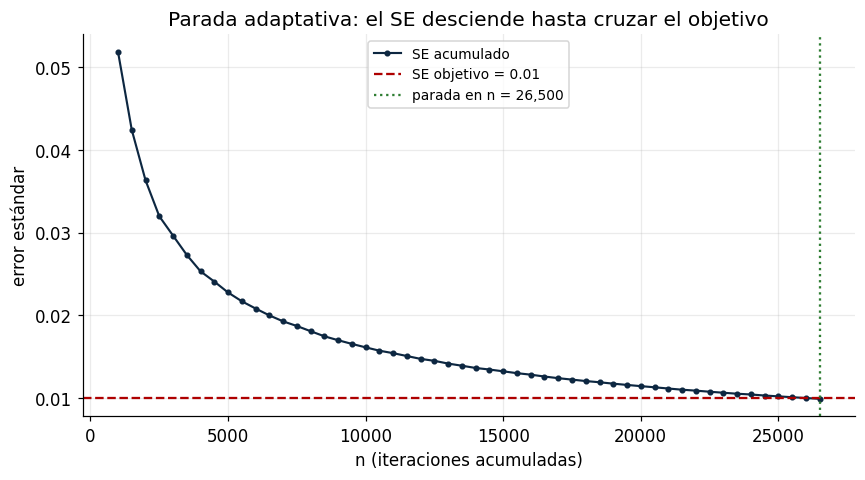

In [7]:
# Trayectoria del error estándar bajo la parada adaptativa (objetivo SE = 0.01)
r = runs[0.01]
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(r['hist_n'], r['hist_se'], "o-", color=NAVY, ms=3, lw=1.4, label="SE acumulado")
ax.axhline(0.01, color=RED, ls="--", lw=1.5, label="SE objetivo = 0.01")
ax.axvline(r['n_final'], color=GREEN, ls=":", lw=1.5,
           label=f"parada en n = {r['n_final']:,}")
ax.set_xlabel("n (iteraciones acumuladas)"); ax.set_ylabel("error estándar")
ax.set_title("Parada adaptativa: el SE desciende hasta cruzar el objetivo")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

## 5. Análisis de convergencia

**¿Qué significa "convergencia"?** Que el estimador se ha **estabilizado** cerca de su valor límite, que la **variabilidad** entre simulaciones adicionales es pequeña, y que el **error estándar** ha alcanzado un nivel aceptable. No implica la respuesta exacta, sino la precisión deseada.

> 🔧 **Método — Técnicas de diagnóstico**
>
> 1. **Media acumulativa:** graficar $\hat{\theta}_k = \frac{1}{k}\sum_{i=1}^{k} g(X_i)$; al converger, la línea se estabiliza.
> 2. **SE acumulativo:** graficar $SE_k = s_k/\sqrt{k}$ en log–log; debe dar una recta de pendiente $-1/2$.
> 3. **Rolling window:** medias por ventanas de tamaño $w$; al converger, ventanas consecutivas son similares.
> 4. **Test de Geweke:** comparar la media del primer 10 % con la del último 50 %; sin diferencia significativa ($p>0.05$) sugiere convergencia.
> 5. **Múltiples *runs*:** repetir con distintas semillas; estimaciones consistentes indican convergencia.

In [8]:
def diagnostico_convergencia(resultados, nombre="Simulación"):
    """Suite de diagnósticos de convergencia."""
    resultados = np.asarray(resultados)
    n      = len(resultados)
    medias = np.cumsum(resultados) / np.arange(1, n + 1)
    # SE acumulado (k=1 no tiene varianza muestral definida -> NaN)
    ses    = np.array([resultados[:k].std(ddof=1) / np.sqrt(k) if k > 1 else np.nan
                       for k in range(1, n + 1)])

    # Rolling window
    w          = max(100, n // 20)
    n_windows  = n // w
    roll_means = [resultados[i*w:(i+1)*w].mean() for i in range(n_windows)]

    # Test de Geweke
    p1 = resultados[:int(0.10 * n)]
    p2 = resultados[int(0.50 * n):]
    z  = (p1.mean() - p2.mean()) / np.sqrt(
          p1.var(ddof=1)/len(p1) + p2.var(ddof=1)/len(p2))
    pval = 2 * (1 - stats.norm.cdf(abs(z)))

    print("=" * 65)
    print(f"DIAGNÓSTICO: {nombre}")
    print("=" * 65)
    print(f"n = {n:,}  |  Estimación: {medias[-1]:.6f}  |  SE: {ses[-1]:.6f}")
    print(f"IC 95 %: [{medias[-1]-1.96*ses[-1]:.6f}, {medias[-1]+1.96*ses[-1]:.6f}]")
    print("\nTest de Geweke:")
    print(f"  Media primeros 10 %: {p1.mean():.6f}")
    print(f"  Media últimos  50 %: {p2.mean():.6f}")
    print(f"  Z = {z:.4f}   p = {pval:.4f}  →  "
          f"{'✓ Convergencia OK' if pval > 0.05 else '⚠ Revisar convergencia'}")
    print(f"\nVariabilidad rolling: CV = "
          f"{np.std(roll_means)/np.mean(roll_means)*100:.2f} %")

# Aplicar al ejemplo
_, _, _, res = monte_carlo_con_se(simular_tiempo_espera, 10_000, 42)
diagnostico_convergencia(res, "Tiempo de Espera en Cola")

DIAGNÓSTICO: Tiempo de Espera en Cola
n = 10,000  |  Estimación: 2.245365  |  SE: 0.016128
IC 95 %: [2.213754, 2.276977]

Test de Geweke:
  Media primeros 10 %: 2.286779
  Media últimos  50 %: 2.261911
  Z = 0.4388   p = 0.6608  →  ✓ Convergencia OK

Variabilidad rolling: CV = 2.76 %


## 6. Visualización de resultados

> 🔑 **Qué reportar y cómo visualizarlo**
>
> **Siempre incluir:** estimación puntual $\hat{\theta}$, error estándar $SE(\hat{\theta})$, intervalo de confianza (típ. 95 %), número de simulaciones $n$ y la semilla (reproducibilidad).

**Formato recomendado:**

```
Estimación: 2.4567 ± 0.0234 (SE)
IC 95%: [2.4108, 2.5026]
Basado en n=10,000 simulaciones  (semilla=42)
```

**Visualizaciones esenciales:** histograma de resultados, media acumulativa (convergencia), SE vs $n$ y, cuando sea relevante, comparación con el valor teórico. La siguiente celda las genera todas.

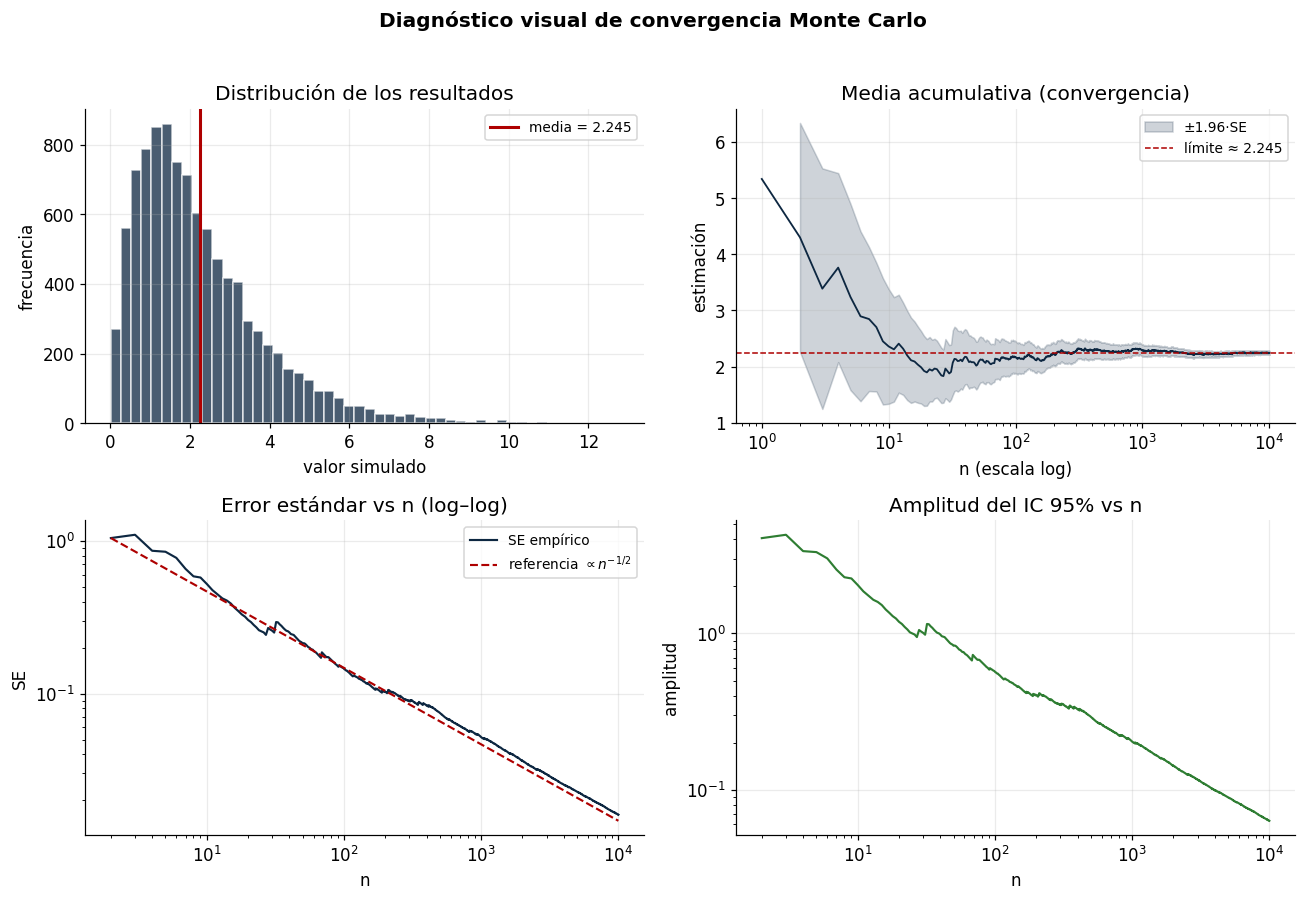

In [9]:
# Diagnóstico visual de convergencia (4 paneles)
_, _, _, res10k = monte_carlo_con_se(simular_tiempo_espera, 10_000, 42)
n = len(res10k)
k = np.arange(1, n + 1)
cmean = np.cumsum(res10k) / k
csum2 = np.cumsum(res10k ** 2)
with np.errstate(invalid="ignore", divide="ignore"):
    cvar = (csum2 - k * cmean ** 2) / (k - 1)    # k=1 -> NaN (ignorado)
    cse  = np.sqrt(cvar / k)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# (a) Histograma
ax = axes[0, 0]
ax.hist(res10k, bins=50, color=NAVY, alpha=0.75, edgecolor="white")
ax.axvline(cmean[-1], color=RED, lw=2, label=f"media = {cmean[-1]:.3f}")
ax.set_title("Distribución de los resultados")
ax.set_xlabel("valor simulado"); ax.set_ylabel("frecuencia"); ax.legend(fontsize=9)

# (b) Media acumulativa ± 1.96·SE
ax = axes[0, 1]
ax.plot(k, cmean, color=NAVY, lw=1.2)
ax.fill_between(k[1:], (cmean - 1.96 * cse)[1:], (cmean + 1.96 * cse)[1:],
                color=NAVY, alpha=0.20, label="±1.96·SE")
ax.axhline(cmean[-1], color=RED, ls="--", lw=1, label=f"límite ≈ {cmean[-1]:.3f}")
ax.set_xscale("log")
ax.set_title("Media acumulativa (convergencia)")
ax.set_xlabel("n (escala log)"); ax.set_ylabel("estimación"); ax.legend(fontsize=9)

# (c) SE vs n (log–log) con pendiente -1/2
ax = axes[1, 0]
ax.loglog(k[1:], cse[1:], color=NAVY, lw=1.4, label="SE empírico")
ref = cse[1] * np.sqrt(k[1] / k[1:])             # recta de referencia ∝ n^(-1/2)
ax.loglog(k[1:], ref, color=RED, ls="--", lw=1.4, label=r"referencia $\propto n^{-1/2}$")
ax.set_title("Error estándar vs n (log–log)")
ax.set_xlabel("n"); ax.set_ylabel("SE"); ax.legend(fontsize=9)

# (d) Amplitud del IC 95 % vs n
ax = axes[1, 1]
ax.loglog(k[1:], (2 * 1.96 * cse)[1:], color=GREEN, lw=1.4)
ax.set_title("Amplitud del IC 95% vs n")
ax.set_xlabel("n"); ax.set_ylabel("amplitud")

fig.suptitle("Diagnóstico visual de convergencia Monte Carlo", y=1.02, fontweight="bold")
plt.tight_layout(); plt.show()

### Reporte completo

Una función que reúne todo lo anterior en un único reporte estadístico (incluye asimetría, curtosis y, si se entrega, comparación con el valor teórico):

In [10]:
def reporte_mc(func, n, nombre="Simulación", valor_teorico=None, random_state=42):
    """Reporte estadístico completo de una simulación Monte Carlo."""
    est, se, ic, res = monte_carlo_con_se(func, n, random_state)
    cv   = se / abs(est) * 100
    skew = stats.skew(res)
    kurt = stats.kurtosis(res)

    print("=" * 65)
    print(f"REPORTE: {nombre}")
    print("=" * 65)
    print(f"Iteraciones: {n:,}   Semilla: {random_state}")
    print(f"\nEstimación:  {est:.6f} ± {se:.6f}  (CV = {cv:.3f} %)")
    print(f"IC 95 %:     [{ic[0]:.6f}, {ic[1]:.6f}]  (amplitud = {ic[1]-ic[0]:.6f})")
    print(f"\nDistribución:")
    print(f"  Mediana:    {np.median(res):.6f}")
    print(f"  Desv. Est.: {res.std(ddof=1):.6f}")
    print(f"  Asimetría:  {skew:.4f}   Curtosis: {kurt:.4f}")
    print(f"  Rango:      [{res.min():.4f}, {res.max():.4f}]")
    if valor_teorico is not None:
        err = abs(est - valor_teorico)
        print(f"\nComparación con valor teórico = {valor_teorico:.6f}:")
        print(f"  Error abs.: {err:.6f}  ({err/abs(valor_teorico)*100:.4f} %)")
        print(f"  ¿Dentro del IC?: {ic[0] <= valor_teorico <= ic[1]}")

# La media teórica del tiempo de espera es 1/0.8 + 1 = 2.25
reporte_mc(simular_tiempo_espera, n=10_000,
           nombre="Tiempo de Espera en Sistema de Colas", valor_teorico=2.25)

REPORTE: Tiempo de Espera en Sistema de Colas
Iteraciones: 10,000   Semilla: 42

Estimación:  2.245365 ± 0.016128  (CV = 0.718 %)
IC 95 %:     [2.213750, 2.276980]  (amplitud = 0.063230)

Distribución:
  Mediana:    1.861662
  Desv. Est.: 1.612839
  Asimetría:  1.4609   Curtosis: 3.0491
  Rango:      [0.0155, 12.7532]

Comparación con valor teórico = 2.250000:
  Error abs.: 0.004635  (0.2060 %)
  ¿Dentro del IC?: True


## 7. Casos especiales

### Eventos raros

> ⚠️ **Desafío de los eventos raros**
>
> Si $P(\text{evento}) = p$ es muy pequeño (p. ej. $p=10^{-5}$): $SE \approx \sqrt{p/n}$, y para $CV=10\%$ se necesita $n \approx 100/p$. Con $p=10^{-5}$ eso son $\approx 10^7$ simulaciones.
>
> **Alternativas:** *importance sampling* (muestrear de una distribución que favorece el evento), *stratified sampling* (sobremuestrear regiones relevantes), *conditional Monte Carlo* y *cross-entropy method*. Lo clave es reconocer cuándo el Monte Carlo estándar es insuficiente.

### Múltiples salidas

> 🔧 **Estrategia para múltiples salidas**
>
> Si cada simulación produce un vector $(Y_1,\ldots,Y_m)$: (1) calcular SE e IC para *cada* salida; (2) el $n$ debe bastar para la salida **más variable**; (3) para inferencia simultánea, aplicar **corrección de Bonferroni** — para $m$ ICs con confianza global $1-\alpha$, usar $1-\alpha/m$ en cada uno. *Ejemplo:* 5 salidas con confianza global 95 % → 99 % en cada IC individual.

In [11]:
# Costo de los eventos raros: n para CV = 10 % según la probabilidad p
# Indicador Bernoulli(p):  SE = sqrt(p(1-p)/n),  CV = SE/p  ->  n = (1-p)/(p·CV²)
cv = 0.10
print(f"{'p (prob. del evento)':>22}  {'n para CV=10%':>16}")
print("-" * 42)
for p in [1e-1, 1e-2, 1e-3, 1e-4, 1e-5]:
    n_req = (1 - p) / (p * cv ** 2)
    print(f"{p:>22.0e}  {n_req:>16,.0f}")
print("\nRegla rápida: para CV=10%, n ≈ 100/p cuando p es pequeño.")

  p (prob. del evento)     n para CV=10%
------------------------------------------
                 1e-01               900
                 1e-02             9,900
                 1e-03            99,900
                 1e-04           999,900
                 1e-05         9,999,900

Regla rápida: para CV=10%, n ≈ 100/p cuando p es pequeño.


## 8. Resumen y recomendaciones

**Checklist de mejores prácticas**

1. **Siempre** reportar el error estándar junto con la estimación.
2. **Siempre** incluir un intervalo de confianza (típ. 95 %).
3. **Documentar** el número de simulaciones y la semilla.
4. Usar una **simulación piloto** para estimar el $n$ necesario.
5. **Visualizar la convergencia** antes de reportar resultados finales.
6. Ejecutar **diagnósticos** (Geweke, rolling windows, múltiples semillas).
7. Si es posible, **comparar con un valor teórico** conocido (validación).
8. Ser **honesto** sobre las limitaciones: si el SE es grande, reconócelo.
9. Considerar el **costo–beneficio**: más simulaciones dan más precisión, pero a mayor costo.

### Guía de referencia

| Objetivo | CV aceptable | $n$ típico | Uso |
|---|---|---|---|
| Exploración inicial | 10–20 % | 1 000 – 10 000 | Prototipos, ideas |
| Análisis estándar | 5–10 % | 10 000 – 100 000 | Decisiones rutinarias |
| Decisiones importantes | 1–5 % | 100 000 – 1 000 000 | Alta responsabilidad |
| Publicación científica | < 1 % | 1 000 000+ | Rigor académico |

### Puntos clave

1. El **error estándar** cuantifica la precisión de las estimaciones Monte Carlo.
2. El SE decae como $1/\sqrt{n}$: la precisión es costosa.
3. **Determinar $n$:** simulación piloto + fórmula, o parada adaptativa.
4. La **convergencia** no es binaria: es un continuo de precisión creciente.
5. Los **diagnósticos visuales** son esenciales: media acumulativa, SE vs $n$, test de Geweke.
6. **Siempre reportar la incertidumbre:** una estimación sin SE/IC está incompleta.
7. Para **eventos raros**, el Monte Carlo estándar puede ser ineficiente; existen técnicas especializadas.
8. La precisión deseada debe balancearse con los **recursos disponibles**.
9. **Validar** comparando con casos conocidos cuando sea posible.

---

> 💡 **Cierre**
>
> En Monte Carlo la pregunta no es solo "¿cuál es la respuesta?", sino también "¿qué tan confiable es?". El error estándar y el análisis de convergencia transforman resultados numéricos en conocimiento cuantificado con su incertidumbre. Una estimación Monte Carlo sin su error estándar es como un experimento sin repeticiones: informativa pero incompleta. Cuantificar y comunicar la incertidumbre es lo que separa el análisis riguroso del cálculo aislado, y es una competencia fundamental en ciencia de datos.